Import TensorFlow

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [3]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nItems in current folder:")
for item in Path(".").iterdir():
    print(item)

Current working directory:
c:\Users\ilyas\Downloads\SpaceLandClassification\SpaceLandMapper\SpaceLandMapper\Notebooks

Items in current folder:
.ipynb_checkpoints
BaselineModel.ipynb
BaselineModel_cleaned.ipynb
BaselineModel_cleaned_fixed.ipynb


In [4]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nItems in current folder:")
for item in Path(".").iterdir():
    print(item)

Current working directory:
c:\Users\ilyas\Downloads\SpaceLandClassification\SpaceLandMapper\SpaceLandMapper\Notebooks

Items in current folder:
.ipynb_checkpoints
BaselineModel.ipynb
BaselineModel_cleaned.ipynb
BaselineModel_cleaned_fixed.ipynb


In [5]:
DATA_DIR = Path("../Data/Raw/EuroSAT_RGB")
assert DATA_DIR.exists(), f"Dataset path not found: {DATA_DIR}"

class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

print("Dataset found:", DATA_DIR)
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Dataset found: ..\Data\Raw\EuroSAT_RGB
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [6]:
image_paths = []
labels = []

for class_name in class_names:
    class_folder = DATA_DIR / class_name
    for img_path in class_folder.glob("*.jpg"):
        image_paths.append(str(img_path))
        labels.append(class_name)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 25563


,filepath,label
0,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
1,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
2,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
3,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop
4,..\Data\Raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_...,AnnualCrop


In [7]:
print("DataFrame shape:", df.shape)
print("\nUnique labels:")
print(sorted(df["label"].unique()))
print("\nMissing values:")
print(df.isnull().sum())

DataFrame shape: (25563, 2)

Unique labels:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Missing values:
filepath    0
label       0
dtype: int64


In [8]:
class_counts = df["label"].value_counts().sort_index()
class_counts

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    1563
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64

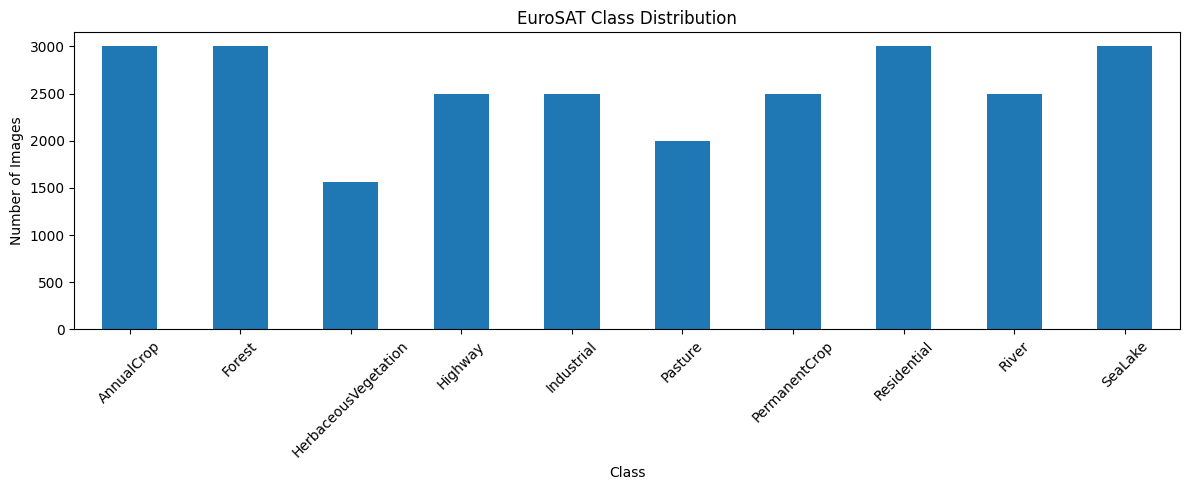

In [9]:
plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("EuroSAT Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

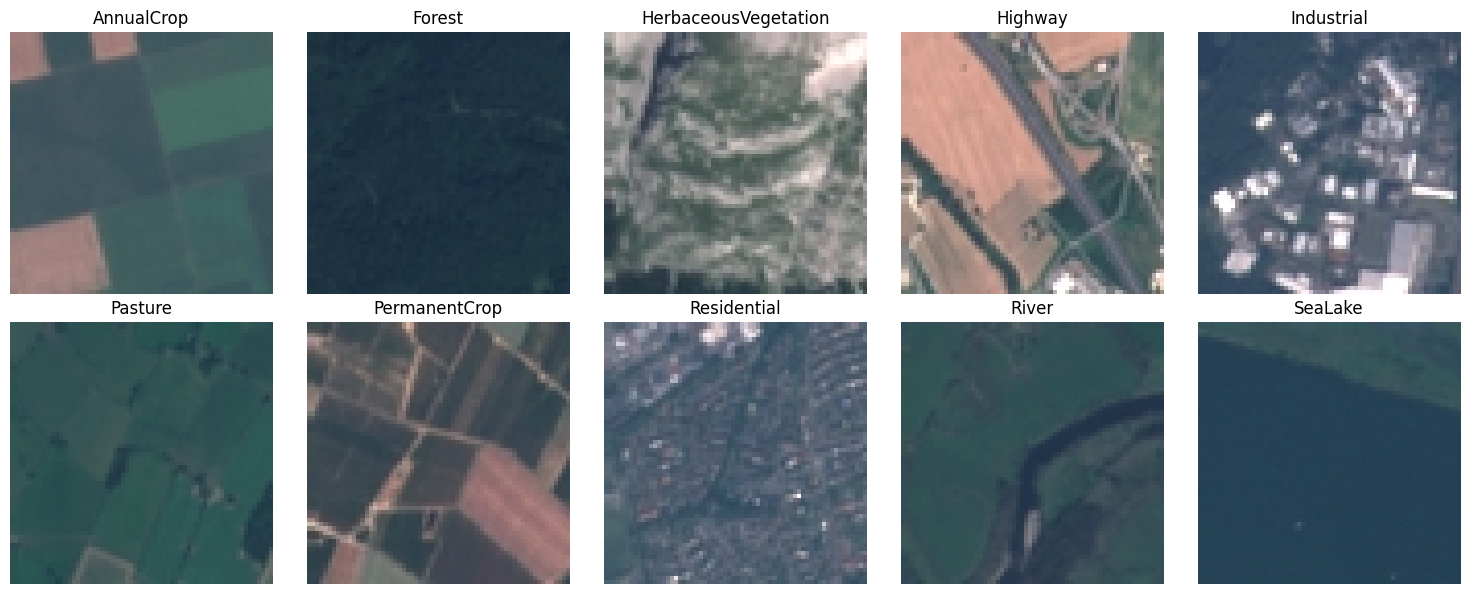

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for ax, class_name in zip(axes, class_names):
    sample_path = df[df["label"] == class_name]["filepath"].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

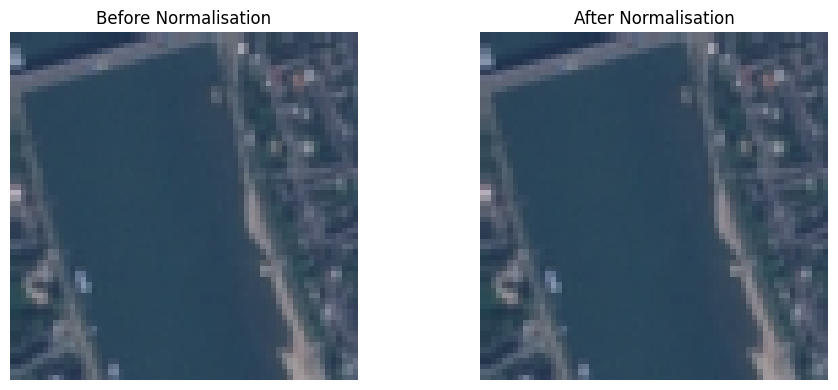

Original range: 30 to 188
Normalised range: 0.11764705882352941 to 0.7372549019607844


In [11]:
sample_path = df["filepath"].sample(1, random_state=SEED).iloc[0]
img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

img_normalized = img_array / 255.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_array)
axes[0].set_title("Before Normalisation")
axes[0].axis("off")

axes[1].imshow(img_normalized)
axes[1].set_title("After Normalisation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Original range:", img_array.min(), "to", img_array.max())
print("Normalised range:", img_normalized.min(), "to", img_normalized.max())

In [12]:


train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 17894
Validation size: 3834
Test size: 3835


In [13]:
split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "val": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index()
})

split_counts

,train,val,test
label,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,1094,234,235
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


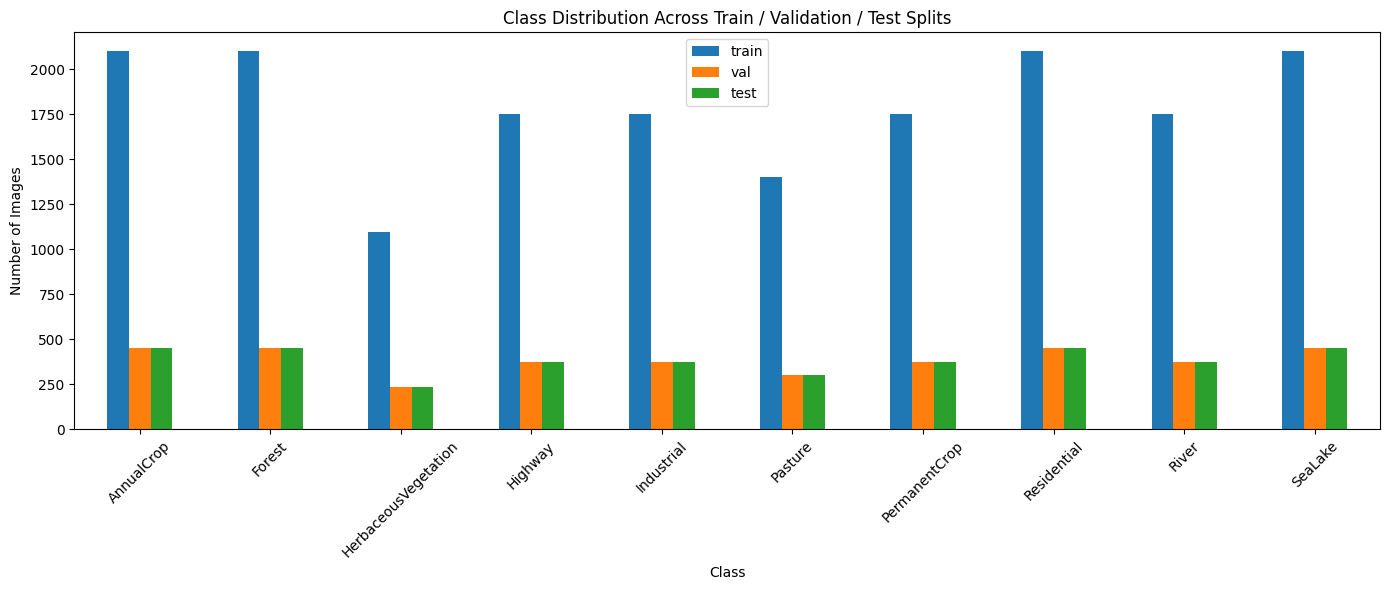

In [14]:
split_counts.plot(kind="bar", figsize=(14, 6))
plt.title("Class Distribution Across Train / Validation / Test Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
split_dir = Path("../Data/Splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved split CSV files to:", split_dir.resolve())

Saved split CSV files to: C:\Users\ilyas\Downloads\SpaceLandClassification\SpaceLandMapper\SpaceLandMapper\Data\Splits


In [16]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

<module 'tensorflow' from 'c:\\Users\\ilyas\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\tensorflow\\__init__.py'>
<class 'module'>
c:\Users\ilyas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\__init__.py
2.16.1
['AggregationMethod', 'Assert', 'CriticalSection', 'DType', 'DeviceSpec', 'GradientTape', 'Graph', 'IndexedSlices', 'IndexedSlicesSpec', 'Module', 'Operation', 'OptionalSpec', 'RaggedTensor', 'RaggedTensorSpec', 'RegisterGradient', 'SparseTensor', 'SparseTensorSpec', 'Tensor', 'TensorArray', 'TensorArraySpec', 'TensorShape', 'TensorSpec', 'TypeSpec', 'UnconnectedGradients', 'Variable', 'VariableAggregation', 'VariableSynchronization', '_API_MODULE', '_KerasLazyLoader', '__all__', '__builtins__', '__cached__', '__compiler_version__', '__cxx11_abi_flag__', '__cxx_version__', '__doc__', '__file__', '__git_version__', '__internal__', '__loader__', '__monolithic_build__', '__name__', '__operators__', '__package__', '__path__', '__spec__', 

In [17]:
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed set for Python, NumPy, and TensorFlow:", SEED)

In [18]:
# Training configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)
class_labels = class_names

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)

TensorFlow version: 2.16.1


## Fixed training setup

This section now includes:
- TensorFlow seed setup
- training constants (`IMG_SIZE`, `BATCH_SIZE`)
- missing baseline CNN imports
- callback imports needed before baseline training
- `class_labels` definition for later evaluation and grid mapping


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [21]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NameError: name 'IMG_SIZE' is not defined

In [ ]:
baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history["accuracy"], label="Train Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Val Accuracy")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_gen)
print("Baseline Test Accuracy:", test_acc)

In [ ]:
model_dir = Path("../Outputs/Models")
model_dir.mkdir(parents=True, exist_ok=True)

baseline_model.save(model_dir / "baseline_cnn.keras")
print("Baseline model saved to:", model_dir.resolve())

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_gen_eff = train_datagen_eff.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen_eff = val_test_datagen_eff.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen_eff = val_test_datagen_eff.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

eff_model = Model(inputs, outputs)

In [ ]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()

In [ ]:
checkpoint_dir = Path("../Outputs/Models")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=checkpoint_dir / "efficientnet_frozen_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history_eff_frozen = eff_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=5,
    steps_per_epoch=150,
    validation_steps=50,
    callbacks=callbacks
)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_frozen.history["accuracy"], label="Train Accuracy")
plt.plot(history_eff_frozen.history["val_accuracy"], label="Val Accuracy")
plt.title("EfficientNet Frozen Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_frozen.history["loss"], label="Train Loss")
plt.plot(history_eff_frozen.history["val_loss"], label="Val Loss")
plt.title("EfficientNet Frozen Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_gen_eff.reset()
test_loss_eff, test_acc_eff = eff_model.evaluate(test_gen_eff)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)

In [ ]:
print("Baseline Test Accuracy:", test_acc)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)

In [ ]:
base_model.trainable = True

# Freeze the earlier layers, unfreeze only the top layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

print("Trainable layers in base model:", sum([layer.trainable for layer in base_model.layers]))

In [ ]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        filepath=checkpoint_dir / "efficientnet_finetuned_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history_eff_finetune = eff_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=5,
    steps_per_epoch=150,
    validation_steps=50,
    callbacks=fine_tune_callbacks
)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_finetune.history["accuracy"], label="Train Accuracy")
plt.plot(history_eff_finetune.history["val_accuracy"], label="Val Accuracy")
plt.title("EfficientNet Fine-Tuned Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_eff_finetune.history["loss"], label="Train Loss")
plt.plot(history_eff_finetune.history["val_loss"], label="Val Loss")
plt.title("EfficientNet Fine-Tuned Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_gen_eff.reset()
test_loss_eff_ft, test_acc_eff_ft = eff_model.evaluate(test_gen_eff)
print("EfficientNet Fine-Tuned Test Accuracy:", test_acc_eff_ft)

In [ ]:
print("Baseline Test Accuracy:", test_acc)
print("EfficientNet Frozen Test Accuracy:", test_acc_eff)
print("EfficientNet Fine-Tuned Test Accuracy:", test_acc_eff_ft)

In [ ]:
final_model_path = checkpoint_dir / "efficientnet_finetuned_best.keras"
print("Final best model saved at:", final_model_path.resolve())

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
test_gen_eff.reset()
pred_probs = eff_model.predict(test_gen_eff)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen_eff.classes
class_labels = list(test_gen_eff.class_indices.keys())

In [ ]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(report)

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - EfficientNetB0 Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
fig_dir = Path("../Outputs/Figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - EfficientNetB0 Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(fig_dir / "confusion_matrix_efficientnet_final.png", dpi=300)
plt.show()

print("Confusion matrix saved to:", fig_dir.resolve())

In [ ]:
final_model = tf.keras.models.load_model("../Outputs/Models/efficientnet_frozen_best.keras")
print("Frozen EfficientNet model loaded successfully.")

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, class_labels):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    pred_class = class_labels[np.argmax(preds)]
    confidence = float(np.max(preds))

    plt.imshow(img)
    plt.title(f"Predicted: {pred_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    return pred_class, confidence

sample_img = "../Data/Raw/EuroSAT_RGB/Highway/Highway_15.jpg"
predict_image(sample_img, final_model, class_labels)

In [ ]:
from PIL import Image, ImageDraw
from collections import Counter

In [ ]:
class_color_map = {
    "AnnualCrop": (255, 215, 0),          # yellow
    "Forest": (34, 139, 34),              # green
    "HerbaceousVegetation": (144, 238, 144),  # light green
    "Highway": (128, 128, 128),           # gray
    "Industrial": (105, 105, 105),        # dark gray
    "Pasture": (189, 183, 107),           # khaki
    "PermanentCrop": (218, 165, 32),      # golden brown
    "Residential": (220, 20, 60),         # red
    "River": (30, 144, 255),              # blue
    "SeaLake": (0, 0, 139)                # dark blue
}

In [ ]:
def predict_tile(tile_img, model, class_labels):
    tile_img = tile_img.resize(IMG_SIZE)
    tile_array = np.array(tile_img).astype("float32") / 255.0
    tile_array = np.expand_dims(tile_array, axis=0)

    preds = model.predict(tile_array, verbose=0)
    pred_class = class_labels[np.argmax(preds)]
    confidence = float(np.max(preds))
    return pred_class, confidence

In [ ]:
def classify_image_in_grid(img_path, model, class_labels, tile_size=64):
    img = Image.open(img_path).convert("RGB")
    width, height = img.size

    grid_predictions = []
    tile_details = []

    for y in range(0, height, tile_size):
        row_predictions = []
        for x in range(0, width, tile_size):
            tile = img.crop((x, y, min(x + tile_size, width), min(y + tile_size, height)))
            pred_class, confidence = predict_tile(tile, model, class_labels)

            row_predictions.append(pred_class)

            tile_details.append({
                "x": x,
                "y": y,
                "predicted_class": pred_class,
                "confidence": confidence
            })

        grid_predictions.append(row_predictions)

    return img, grid_predictions, tile_details

In [ ]:
def create_color_grid_map(original_img, tile_details, class_color_map, tile_size=64):
    width, height = original_img.size
    color_map_img = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(color_map_img)

    for tile in tile_details:
        x = tile["x"]
        y = tile["y"]
        pred_class = tile["predicted_class"]
        color = class_color_map.get(pred_class, (0, 0, 0))

        draw.rectangle(
            [x, y, min(x + tile_size, width), min(y + tile_size, height)],
            fill=color
        )

    return color_map_img

In [ ]:
print(f"Test set size: {len(test_df)}")
test_df.head()

In [ ]:
# Dataset split already created earlier.
# No need to recreate train_df, val_df, and test_df here.

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

In [ ]:
grid_img_path = test_df["filepath"].iloc[0]
print(grid_img_path)

In [ ]:
original_img, grid_predictions, tile_details = classify_image_in_grid(
    grid_img_path,
    final_model,
    class_labels,
    tile_size=64
)

print("original_img type:", type(original_img))
print("grid_predictions type:", type(grid_predictions))
print("tile_details type:", type(tile_details))
print("First tile detail:", tile_details[0])

In [ ]:
color_map_img = create_color_grid_map(
    original_img,
    tile_details,
    class_color_map,
    tile_size=64
)

print("color_map_img type:", type(color_map_img))

In [ ]:
counts, percentages = calculate_class_percentages(tile_details)

print("Tile counts:", counts)
print("Class percentages:", percentages)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(color_map_img)
axes[1].set_title("Grid-Based Land Classification Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
percentages_sorted = dict(sorted(percentages.items(), key=lambda x: x[1], reverse=True))

for cls, pct in percentages_sorted.items():
    print(f"{cls}: {pct}%")

In [ ]:
custom_img_path = "../Data/TestImages/TestImage.png"

original_img, grid_predictions, tile_details = classify_image_in_grid(
    custom_img_path,
    final_model,
    class_labels,
    tile_size=64
)

color_map_img = create_color_grid_map(
    original_img,
    tile_details,
    class_color_map,
    tile_size=64
)

counts, percentages = calculate_class_percentages(tile_details)

print("Tile counts:", counts)
print("Class percentages:", percentages)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(original_img)
axes[0].set_title("Original Large Satellite Image")
axes[0].axis("off")

axes[1].imshow(color_map_img)
axes[1].set_title("Grid-Based Land Classification Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
percentages_sorted = dict(sorted(percentages.items(), key=lambda x: x[1], reverse=True))

for cls, pct in percentages_sorted.items():
    print(f"{cls}: {pct}%")

In [ ]:
output_dir = Path("../Outputs/Figures")
output_dir.mkdir(parents=True, exist_ok=True)

color_map_img.save(output_dir / "grid_land_classification_map.png")
print("Saved map to:", (output_dir / "grid_land_classification_map.png").resolve())